In [1]:
from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np

data = load_diabetes()

X = data.data
y = data.target

X.shape, y.shape

((442, 10), (442,))

In [2]:
X = np.c_[np.ones(X.shape[0]), X]

X.shape

(442, 11)

In [3]:
w = np.zeros(X.shape[1])

In [4]:
y_pred = X @ w

In [5]:
def batch_gradient_descent(X, y, learning_rate=0.1, epochs=1000):

    n_samples = X.shape[0]

    w = np.zeros(X.shape[1])

    losses = []

    for epoch in range(epochs):

        # prediction
        y_pred = X @ w

        # error
        error = y_pred - y

        # loss
        loss = np.mean(error ** 2)
        losses.append(loss)

        # gradient
        gradient = (2 / n_samples) * (X.T @ error)

        # update weights
        w = w - learning_rate * gradient

    return w, losses

In [6]:
w_batch, losses_batch = batch_gradient_descent(X, y)

w_batch

array([ 152.13348416,   48.24658226,  -32.92726854,  258.93018438,
        180.81212084,   36.22954144,   10.73130635, -148.31320668,
        133.89614088,  229.53250321,  128.55950125])

In [7]:
losses_batch[-1]

np.float64(3408.961953188592)

In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X[:, 1:], y)

model.coef_, model.intercept_

(array([ -10.0098663 , -239.81564367,  519.84592005,  324.3846455 ,
        -792.17563855,  476.73902101,  101.04326794,  177.06323767,
         751.27369956,   67.62669218]),
 np.float64(152.13348416289597))

In [9]:
def stochastic_gradient_descent(X, y, learning_rate=0.01, epochs=100):

    n_samples = X.shape[0]

    w = np.zeros(X.shape[1])

    losses = []

    for epoch in range(epochs):

        # shuffle data
        indices = np.random.permutation(n_samples)

        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(n_samples):

            x_i = X_shuffled[i]
            y_i = y_shuffled[i]

            # prediction
            y_pred = x_i @ w

            # error
            error = y_pred - y_i

            # gradient for ONE sample
            gradient = 2 * x_i * error

            # update
            w = w - learning_rate * gradient

        # calculate full-dataset loss
        y_pred_all = X @ w
        loss = np.mean((y_pred_all - y) ** 2)

        losses.append(loss)

    return w, losses

In [11]:
w_sgd, losses_sgd = stochastic_gradient_descent(X, y)

w_sgd

array([ 158.58791424,   10.5677823 , -185.88457711,  475.47861614,
        297.51651061,  -37.07937456, -100.40831688, -206.27263664,
        129.8558715 ,  396.2309511 ,  122.78634032])

In [12]:
def mini_batch_gradient_descent(
    X,
    y,
    learning_rate=0.01,
    epochs=100,
    batch_size=32
):

    n_samples = X.shape[0]

    w = np.zeros(X.shape[1])

    losses = []

    for epoch in range(epochs):

        # shuffle
        indices = np.random.permutation(n_samples)

        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for start in range(0, n_samples, batch_size):

            end = start + batch_size

            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            # prediction
            y_pred = X_batch @ w

            # error
            error = y_pred - y_batch

            # gradient
            gradient = (
                2 / len(X_batch)
            ) * (X_batch.T @ error)

            # update
            w = w - learning_rate * gradient

        # full dataset loss
        y_pred_all = X @ w
        loss = np.mean((y_pred_all - y) ** 2)

        losses.append(loss)

    return w, losses

In [14]:
w_mini, losses_mini = mini_batch_gradient_descent(
    X,
    y,
    batch_size=32
)

w_mini

array([151.90465851,  16.54181755,   2.28046626,  55.30709263,
        41.14940262,  17.87493365,  14.00628734, -36.33148272,
        38.57453413,  52.5559095 ,  34.69958453])

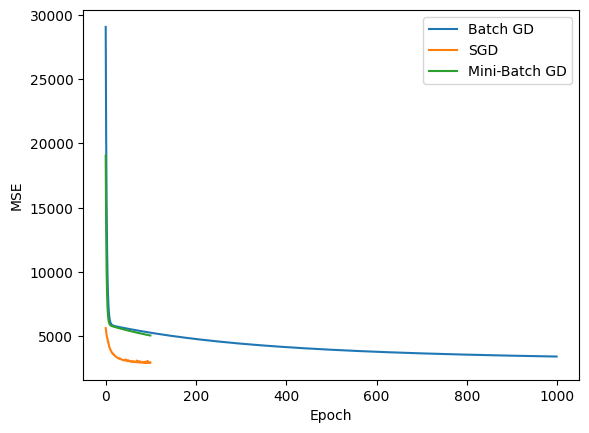

In [15]:
import matplotlib.pyplot as plt

plt.plot(losses_batch, label="Batch GD")
plt.plot(losses_sgd, label="SGD")
plt.plot(losses_mini, label="Mini-Batch GD")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()